# Chapter 11: K-Nearest Neighbors

MATH 4230 Capstone Project  
Dataset: Student Lifestyle, Mental Health and Burnout Insight

<div style="text-align:center; font-style:italic;">
K-nearest neighbors tests whether students with similar profiles share similar risk outcomes, but its value as a screening tool depends on whether the accuracy gain is worth losing the interpretability of logistic regression.
</div>

## Setup

In [5]:
# Standard library
import os
import warnings

# Data science stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Scikit-learn
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# Settings
warnings.filterwarnings("ignore")
RANDOM_STATE = 230
np.random.seed(RANDOM_STATE)

plt.rcParams["savefig.dpi"] = 150
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
sns.set_style("whitegrid")

# Output directories
FIGURES_DIR = "../figures/ch11/"
RESULTS_DIR = "../results/ch11/"
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print("Setup complete.")
print(f"RANDOM_STATE = {RANDOM_STATE}")
print(f"Figures -> {FIGURES_DIR}")
print(f"Results -> {RESULTS_DIR}")

Setup complete.
RANDOM_STATE = 230
Figures -> ../figures/ch11/
Results -> ../results/ch11/


## §1. The Question

Among students with similar sleep hours, physical activity levels, and social support scores, how many neighbors sharing a similar profile must agree before a mental health risk classification is reliable?

## §2. Method in Brief

K-nearest neighbors classifies a new student by finding the most similar students in the training data, usually using Euclidean distance. The model then assigns the class that receives the majority vote among the nearest neighbors.

KNN is non-parametric, meaning it does not estimate a fixed equation or coefficient table. The main tuning choice is K, the number of neighbors used for the vote. A very small K can overreact to noise, while a very large K can smooth away meaningful local patterns. This creates a bias-variance tradeoff.

## §3. Why This Method?

KNN is useful here because it asks whether students with similar overall profiles also have similar mental health risk outcomes. Unlike logistic regression, KNN does not assume a linear relationship between the predictors and the outcome. Unlike SVM, it does not try to find a global decision boundary. Instead, it looks locally around each student and classifies based on nearby examples. If KNN performs well, that suggests student risk profiles form meaningful local neighborhoods in the feature space. If it does not improve over logistic regression or SVM, then the added computational cost and loss of interpretability are difficult to justify.

## §4. Data Setup

This chapter uses the same Chapter 2 split used throughout Chapters 3 through 12. The model is trained on a stratified 30,000-row subsample of the training set to keep KNN computation reasonable. The full test set is still used for final evaluation. All features were already standardized in Chapter 2, which is critical for KNN because distance-based methods are sensitive to feature scale.

In [6]:
# Load arrays from Chapter 2
X_train = np.load("../results/X_train.npy")
X_test = np.load("../results/X_test.npy")
y_train_cls = np.load("../results/y_train_cls.npy")
y_test_cls = np.load("../results/y_test_cls.npy")
feature_names = joblib.load("../results/feature_names.pkl")

# Make the target binary if a three-class target was saved.
# If labels are 0, 1, 2, treat High = 2 as the positive class.
# If labels are already 0 and 1, keep them as they are.
if np.max(y_train_cls) > 1:
    y_train_bin = (y_train_cls == 2).astype(int)
    y_test_bin = (y_test_cls == 2).astype(int)
else:
    y_train_bin = y_train_cls.astype(int)
    y_test_bin = y_test_cls.astype(int)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape : {X_test.shape}")
print(f"y_train_bin shape: {y_train_bin.shape}")
print(f"y_test_bin shape : {y_test_bin.shape}")
print(f"Number of features: {len(feature_names)}")

print()
print("Binary class distribution in training data:")
unique, counts = np.unique(y_train_bin, return_counts=True)
for label, count in zip(unique, counts):
    print(f"  Class {label}: {count:,} ({count / len(y_train_bin) * 100:.2f}%)")

X_train shape: (140000, 19)
X_test shape : (40000, 19)
y_train_bin shape: (140000,)
y_test_bin shape : (40000,)
Number of features: 19

Binary class distribution in training data:
  Class 0: 137,889 (98.49%)
  Class 1: 2,111 (1.51%)


In [7]:
# Stratified 30,000-row subsample for KNN fitting and cross-validation
SUBSAMPLE_N = 30_000

X_knn, _, y_knn, _ = train_test_split(
    X_train,
    y_train_bin,
    train_size=SUBSAMPLE_N,
    stratify=y_train_bin,
    random_state=RANDOM_STATE
)

print(f"KNN subsample shape: {X_knn.shape}")
print("Subsample class distribution:")
unique, counts = np.unique(y_knn, return_counts=True)
for label, count in zip(unique, counts):
    print(f"  Class {label}: {count:,} ({count / len(y_knn) * 100:.2f}%)")

KNN subsample shape: (30000, 19)
Subsample class distribution:
  Class 0: 29,548 (98.49%)
  Class 1: 452 (1.51%)


## §5. Analysis

The K search is summarized with a readable figure and a concise tuning table. The full K tuning table is still saved to the results folder, but the main chapter should only show the most important rows so the report does not become crowded.

### K Search with 5-Fold Stratified Cross-Validation

Odd K values from 1 to 50 are tested so ties are less likely during majority voting. The best K is selected using 5-fold stratified cross-validation on the 30,000-row subsample.

In [8]:
# Search odd K values from 1 to 50
k_values = list(range(1, 51, 2))
skf5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_acc = []
cv_std = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    scores = cross_val_score(
        model,
        X_knn,
        y_knn,
        cv=skf5,
        scoring="accuracy",
        n_jobs=-1
    )
    cv_acc.append(scores.mean())
    cv_std.append(scores.std())
    print(f"K={k:2d}  CV accuracy={scores.mean():.4f}  std={scores.std():.4f}")

cv_acc = np.array(cv_acc)
cv_std = np.array(cv_std)

best_idx = np.argmax(cv_acc)
best_k = k_values[best_idx]
best_cv_acc = cv_acc[best_idx]
best_cv_std = cv_std[best_idx]

print()
print(f"Best K: {best_k}")
print(f"Best CV accuracy: {best_cv_acc:.4f} (+/- {best_cv_std:.4f})")

K= 1  CV accuracy=0.9801  std=0.0007
K= 3  CV accuracy=0.9843  std=0.0007
K= 5  CV accuracy=0.9851  std=0.0005
K= 7  CV accuracy=0.9853  std=0.0003
K= 9  CV accuracy=0.9857  std=0.0004
K=11  CV accuracy=0.9855  std=0.0002
K=13  CV accuracy=0.9855  std=0.0003
K=15  CV accuracy=0.9856  std=0.0003
K=17  CV accuracy=0.9856  std=0.0002
K=19  CV accuracy=0.9855  std=0.0002
K=21  CV accuracy=0.9855  std=0.0002
K=23  CV accuracy=0.9854  std=0.0002
K=25  CV accuracy=0.9854  std=0.0002
K=27  CV accuracy=0.9853  std=0.0003
K=29  CV accuracy=0.9853  std=0.0002
K=31  CV accuracy=0.9853  std=0.0001
K=33  CV accuracy=0.9853  std=0.0002
K=35  CV accuracy=0.9853  std=0.0002
K=37  CV accuracy=0.9852  std=0.0001
K=39  CV accuracy=0.9852  std=0.0001
K=41  CV accuracy=0.9852  std=0.0001
K=43  CV accuracy=0.9851  std=0.0002
K=45  CV accuracy=0.9851  std=0.0002
K=47  CV accuracy=0.9851  std=0.0002
K=49  CV accuracy=0.9852  std=0.0002

Best K: 9
Best CV accuracy: 0.9857 (+/- 0.0004)


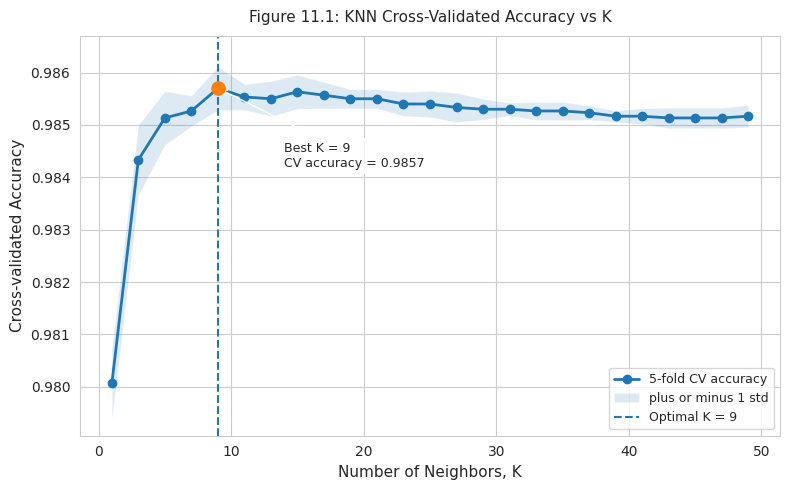

Saved: ../figures/ch11/figure_11_1_accuracy_vs_k.png


In [9]:
# Figure 11.1: Cross-validated accuracy vs K
# The y-axis is zoomed to the observed accuracy range so the differences between K values are visible.

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(k_values, cv_acc, marker="o", linewidth=2, label="5-fold CV accuracy")
ax.fill_between(
    k_values,
    cv_acc - cv_std,
    cv_acc + cv_std,
    alpha=0.15,
    label="plus or minus 1 std"
)

ax.axvline(best_k, linestyle="--", linewidth=1.5, label=f"Optimal K = {best_k}")
ax.scatter([best_k], [best_cv_acc], s=90, zorder=5)

ax.annotate(
    f"Best K = {best_k}\nCV accuracy = {best_cv_acc:.4f}",
    xy=(best_k, best_cv_acc),
    xytext=(best_k + 5, best_cv_acc - 0.0015),
    arrowprops=dict(arrowstyle="->", lw=1.0),
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8)
)

y_min = max(0, cv_acc.min() - 0.001)
y_max = min(1.0, cv_acc.max() + 0.001)
ax.set_ylim(y_min, y_max)

ax.set_xlabel("Number of Neighbors, K", fontsize=11)
ax.set_ylabel("Cross-validated Accuracy", fontsize=11)
ax.set_title("Figure 11.1: KNN Cross-Validated Accuracy vs K", fontsize=11, pad=10)
ax.legend(fontsize=9, loc="lower right")

plt.tight_layout()
fig_path_111 = os.path.join(FIGURES_DIR, "figure_11_1_accuracy_vs_k.png")
plt.savefig(fig_path_111, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {fig_path_111}")

### Visualization Justification

The KNN accuracy plots use a zoomed y-axis because the model accuracy values are all close to 0.98 due to class imbalance. Without zooming, the differences between K values would be visually compressed and the selected K would be hard to interpret. The confusion matrix also includes row percentages so the reader can see that the High-risk class recall is low even though the overall accuracy is high.

### Bias-Variance Check

Figure 11.2 compares training accuracy and test accuracy as K changes. This plot is useful for diagnostics, but it should be read together with Figure 11.1 because accuracy is very high for most K values due to the strong class imbalance.

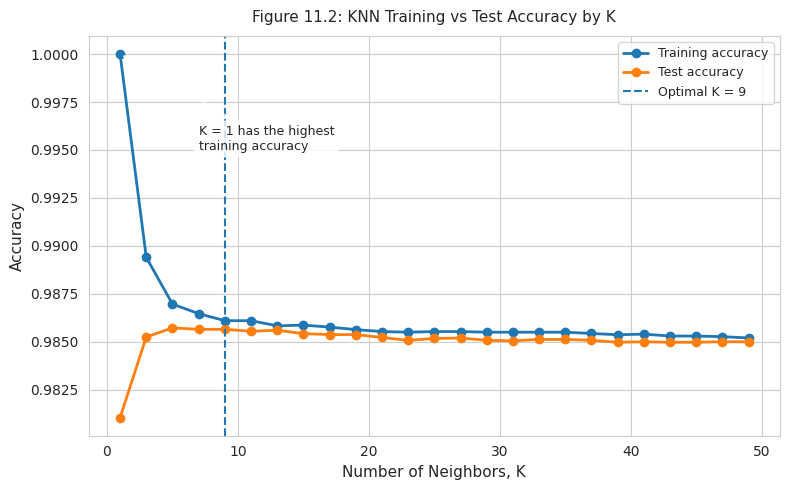

Saved: ../figures/ch11/figure_11_2_train_test_accuracy_vs_k.png


In [10]:
# Figure 11.2: Training vs test accuracy across K values
# This plot checks whether small K values overfit and whether large K values oversmooth the classifier.

train_acc = []
test_acc = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    model.fit(X_knn, y_knn)

    train_pred = model.predict(X_knn)
    test_pred = model.predict(X_test)

    train_acc.append(accuracy_score(y_knn, train_pred))
    test_acc.append(accuracy_score(y_test_bin, test_pred))

train_acc = np.array(train_acc)
test_acc = np.array(test_acc)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(k_values, train_acc, marker="o", linewidth=2, label="Training accuracy")
ax.plot(k_values, test_acc, marker="o", linewidth=2, label="Test accuracy")
ax.axvline(best_k, linestyle="--", linewidth=1.5, label=f"Optimal K = {best_k}")

ax.annotate(
    "K = 1 has the highest\ntraining accuracy",
    xy=(1, train_acc[0]),
    xytext=(7, train_acc[0] - 0.005),
    arrowprops=dict(arrowstyle="->", lw=1.0),
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8)
)

ax.set_xlabel("Number of Neighbors, K", fontsize=11)
ax.set_ylabel("Accuracy", fontsize=11)
ax.set_title("Figure 11.2: KNN Training vs Test Accuracy by K", fontsize=11, pad=10)
ax.legend(fontsize=9, loc="upper right")

plt.tight_layout()
fig_path_112 = os.path.join(FIGURES_DIR, "figure_11_2_train_test_accuracy_vs_k.png")
plt.savefig(fig_path_112, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {fig_path_112}")

### Final KNN Model

The final KNN model is fit using the optimal K from cross-validation and evaluated on the full 40,000-row test set.

In [11]:
# Fit final KNN model
knn_final = KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1)
knn_final.fit(X_knn, y_knn)

y_pred_knn = knn_final.predict(X_test)
y_score_knn = knn_final.predict_proba(X_test)[:, 1]

knn_accuracy = accuracy_score(y_test_bin, y_pred_knn)
knn_auc = roc_auc_score(y_test_bin, y_score_knn)

report_knn = classification_report(
    y_test_bin,
    y_pred_knn,
    target_names=["Low", "High"],
    output_dict=True
)

knn_precision_high = report_knn["High"]["precision"]
knn_recall_high = report_knn["High"]["recall"]
knn_f1_high = report_knn["High"]["f1-score"]

print(f"KNN final model, K = {best_k}")
print(f"Accuracy : {knn_accuracy:.4f}")
print(f"High precision: {knn_precision_high:.4f}")
print(f"High recall   : {knn_recall_high:.4f}")
print(f"High F1       : {knn_f1_high:.4f}")
print(f"AUC-ROC       : {knn_auc:.4f}")
print()
print(classification_report(y_test_bin, y_pred_knn, target_names=["Low", "High"]))

KNN final model, K = 9
Accuracy : 0.9857
High precision: 0.7458
High recall   : 0.0730
High F1       : 0.1329
AUC-ROC       : 0.8449

              precision    recall  f1-score   support

         Low       0.99      1.00      0.99     39397
        High       0.75      0.07      0.13       603

    accuracy                           0.99     40000
   macro avg       0.87      0.54      0.56     40000
weighted avg       0.98      0.99      0.98     40000



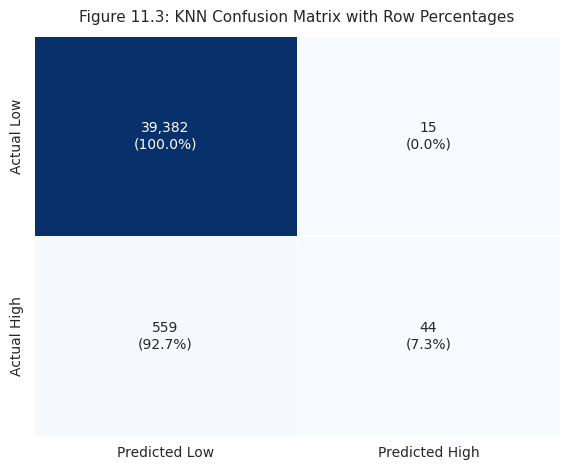

Saved: ../figures/ch11/figure_11_3_confusion_matrix.png


In [12]:
# Figure 11.3: Confusion matrix with counts and row percentages
# Row percentages make the minority High-risk class performance easier to interpret.

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_bin, y_pred_knn)
row_pct = cm / cm.sum(axis=1, keepdims=True)

labels = np.array([
    [f"{cm[i, j]:,}\n({row_pct[i, j] * 100:.1f}%)" for j in range(cm.shape[1])]
    for i in range(cm.shape[0])
])

fig, ax = plt.subplots(figsize=(5.8, 4.8))

sns.heatmap(
    cm,
    annot=labels,
    fmt="",
    cmap="Blues",
    cbar=False,
    xticklabels=["Predicted Low", "Predicted High"],
    yticklabels=["Actual Low", "Actual High"],
    linewidths=0.5,
    linecolor="white",
    ax=ax
)

ax.set_title("Figure 11.3: KNN Confusion Matrix with Row Percentages", fontsize=11, pad=10)
ax.set_xlabel("")
ax.set_ylabel("")

plt.tight_layout()
fig_path_113 = os.path.join(FIGURES_DIR, "figure_11_3_confusion_matrix.png")
plt.savefig(fig_path_113, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {fig_path_113}")

## §6. Diagnostics and Tuning

The main tuning parameter is K. Small values of K create a flexible, high-variance classifier that can follow local noise. Larger values of K create a smoother, higher-bias classifier that may ignore smaller pockets of High-risk students. The optimal K balances those two forces by maximizing cross-validated accuracy on the stratified training subsample.

In [13]:
# Fit a logistic regression baseline from Chapter 5 structure for ROC comparison.
# This is trained on the same 30,000-row subsample so the ROC comparison is directly reproducible here.
log_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_model.fit(X_knn, y_knn)

log_score = log_model.predict_proba(X_test)[:, 1]
log_pred = log_model.predict(X_test)

log_accuracy = accuracy_score(y_test_bin, log_pred)
log_auc = roc_auc_score(y_test_bin, log_score)

log_report = classification_report(
    y_test_bin,
    log_pred,
    target_names=["Low", "High"],
    output_dict=True
)

log_f1_high = log_report["High"]["f1-score"]

print("Logistic regression baseline fit for Chapter 11 comparison")
print(f"Accuracy: {log_accuracy:.4f}")
print(f"High F1 : {log_f1_high:.4f}")
print(f"AUC-ROC : {log_auc:.4f}")

Logistic regression baseline fit for Chapter 11 comparison
Accuracy: 0.9875
High F1 : 0.4344
AUC-ROC : 0.9821


In [14]:
# Optional prior SVM result lookup from Chapter 10 if available
svm_row = {
    "Method": "SVM",
    "Optimal K": "N/A",
    "CV Accuracy": "N/A",
    "Test Accuracy": np.nan,
    "High F1": np.nan,
    "AUC-ROC": np.nan,
    "Source": "Chapter 10 results not found"
}

possible_svm_paths = [
    "../results/ch10/svm_results.csv",
    "../results/ch10/support_vector_machines_results.csv"
]

for path in possible_svm_paths:
    if os.path.exists(path):
        svm_df = pd.read_csv(path)
        print(f"Loaded prior SVM results from {path}")
        print(svm_df.head())

        # Try to select the RBF SVM row first, otherwise use the last row.
        if "Kernel" in svm_df.columns:
            mask = svm_df["Kernel"].astype(str).str.lower().str.contains("rbf")
            selected = svm_df[mask].iloc[0] if mask.any() else svm_df.iloc[-1]
        elif "Method" in svm_df.columns:
            mask = svm_df["Method"].astype(str).str.lower().str.contains("rbf")
            selected = svm_df[mask].iloc[0] if mask.any() else svm_df.iloc[-1]
        else:
            selected = svm_df.iloc[-1]

        def safe_get(row, names):
            for name in names:
                if name in row.index:
                    return row[name]
            return np.nan

        svm_row = {
            "Method": "SVM",
            "Optimal K": "N/A",
            "CV Accuracy": "N/A",
            "Test Accuracy": safe_get(selected, ["Accuracy", "Test Accuracy"]),
            "High F1": safe_get(selected, ["F1", "High F1", "F1-score"]),
            "AUC-ROC": safe_get(selected, ["AUC-ROC", "AUC", "Test AUC"]),
            "Source": path
        }
        break

print("SVM comparison row:")
print(svm_row)

Loaded prior SVM results from ../results/ch10/svm_results.csv
                Method  Kernel  Best C  Best Gamma  Accuracy  High-risk F1  \
0  Logistic Regression     NaN     NaN         NaN    0.9873        0.4258   
1           Linear SVM  linear    0.01         NaN    0.9853        0.0639   
2              RBF SVM     rbf    0.10        0.01    0.9849        0.0000   

   AUC-ROC  
0   0.9827  
1   0.9818  
2   0.9748  
SVM comparison row:
{'Method': 'SVM', 'Optimal K': 'N/A', 'CV Accuracy': 'N/A', 'Test Accuracy': np.float64(0.9849), 'High F1': nan, 'AUC-ROC': np.float64(0.9748), 'Source': '../results/ch10/svm_results.csv'}


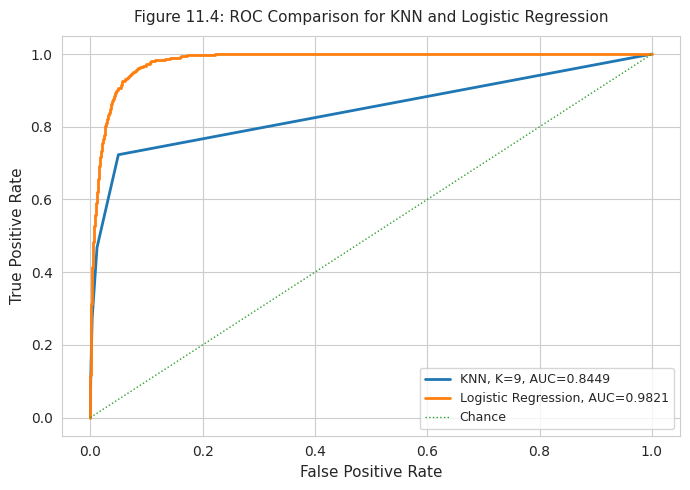

Saved: ../figures/ch11/figure_11_4_roc_comparison.png


In [15]:
# Figure 11.4: ROC curve for optimal KNN vs logistic regression

fpr_knn, tpr_knn, _ = roc_curve(y_test_bin, y_score_knn)
fpr_log, tpr_log, _ = roc_curve(y_test_bin, log_score)

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(fpr_knn, tpr_knn, linewidth=2, label=f"KNN, K={best_k}, AUC={knn_auc:.4f}")
ax.plot(fpr_log, tpr_log, linewidth=2, label=f"Logistic Regression, AUC={log_auc:.4f}")
ax.plot([0, 1], [0, 1], linestyle=":", linewidth=1, label="Chance")

ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.set_title("Figure 11.4: ROC Comparison for KNN and Logistic Regression", fontsize=11, pad=10)
ax.legend(fontsize=9, loc="lower right")

plt.tight_layout()
fig_path_114 = os.path.join(FIGURES_DIR, "figure_11_4_roc_comparison.png")
plt.savefig(fig_path_114, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {fig_path_114}")

In [16]:
# Table 11.1: Concise KNN tuning summary
# The full tuning table is saved for Appendix C, while the main chapter shows the strongest rows.

tuning_df = pd.DataFrame({
    "K": k_values,
    "CV Accuracy": cv_acc.round(4),
    "CV Std": cv_std.round(4),
    "Training Accuracy": train_acc.round(4),
    "Test Accuracy": test_acc.round(4)
})

top_k_tuning_df = (
    tuning_df
    .sort_values(["CV Accuracy", "Test Accuracy"], ascending=[False, False])
    .head(10)
    .sort_values("K")
)

print("Table 11.1: Top KNN tuning results, limited to the 10 strongest K values by CV accuracy.")
display(top_k_tuning_df)

full_tuning_path = os.path.join(RESULTS_DIR, "knn_full_tuning_results_appendix.csv")
tuning_df.to_csv(full_tuning_path, index=False)

print(f"Full tuning table saved for Appendix C: {full_tuning_path}")

Table 11.1: Top KNN tuning results, limited to the 10 strongest K values by CV accuracy.


,K,CV Accuracy,CV Std,Training Accuracy,Test Accuracy
3,7,0.9853,0.0003,0.9865,0.9856
4,9,0.9857,0.0004,0.9861,0.9856
5,11,0.9855,0.0002,0.9861,0.9856
6,13,0.9855,0.0003,0.9858,0.9856
7,15,0.9856,0.0003,0.9859,0.9854
8,17,0.9856,0.0002,0.9858,0.9854
9,19,0.9855,0.0002,0.9856,0.9854
10,21,0.9855,0.0002,0.9855,0.9852
11,23,0.9854,0.0002,0.9855,0.9851
12,25,0.9854,0.0002,0.9855,0.9852


Full tuning table saved for Appendix C: ../results/ch11/knn_full_tuning_results_appendix.csv


## §7. Findings

In [17]:
# Table 11.2: Model comparison against logistic regression and SVM

# Fix SVM row if the Chapter 10 results use High-risk F1 instead of High F1
if isinstance(svm_row, dict) and pd.isna(svm_row.get("High F1", np.nan)):
    possible_svm_paths = [
        "../results/ch10/svm_results.csv",
        "../results/ch10/support_vector_machines_results.csv"
    ]
    for path in possible_svm_paths:
        if os.path.exists(path):
            svm_df = pd.read_csv(path)
            if "Kernel" in svm_df.columns:
                mask = svm_df["Kernel"].astype(str).str.lower().str.contains("rbf")
                selected = svm_df[mask].iloc[0] if mask.any() else svm_df.iloc[-1]
            else:
                selected = svm_df.iloc[-1]
            if "High-risk F1" in selected.index:
                svm_row["High F1"] = selected["High-risk F1"]
            break

findings_rows = [
    {
        "Method": "KNN",
        "Optimal K": best_k,
        "CV Accuracy": round(best_cv_acc, 4),
        "Test Accuracy": round(knn_accuracy, 4),
        "High F1": round(knn_f1_high, 4),
        "AUC-ROC": round(knn_auc, 4),
        "Source": "Chapter 11"
    },
    {
        "Method": "Logistic Regression",
        "Optimal K": "N/A",
        "CV Accuracy": "N/A",
        "Test Accuracy": round(log_accuracy, 4),
        "High F1": round(log_f1_high, 4),
        "AUC-ROC": round(log_auc, 4),
        "Source": "Refit in Chapter 11 for ROC comparison"
    },
    svm_row
]

results_df = pd.DataFrame(findings_rows)

print("Table 11.2: Chapter 11 comparison of KNN, logistic regression, and SVM.")
display(results_df)

results_path = os.path.join(RESULTS_DIR, "knn_results.csv")
results_df.to_csv(results_path, index=False)

tuning_path = os.path.join(RESULTS_DIR, "knn_tuning_results.csv")
tuning_df.to_csv(tuning_path, index=False)

print()
print(f"Saved: {results_path}")
print(f"Saved: {tuning_path}")

Table 11.2: Chapter 11 comparison of KNN, logistic regression, and SVM.


,Method,Optimal K,CV Accuracy,Test Accuracy,High F1,AUC-ROC,Source
0,KNN,9,0.9857,0.9857,0.1329,0.8449,Chapter 11
1,Logistic Regression,N/A,N/A,0.9875,0.4344,0.9821,Refit in Chapter 11 for ROC comparison
2,SVM,N/A,N/A,0.9849,0.0000,0.9748,../results/ch10/svm_results.csv



Saved: ../results/ch11/knn_results.csv
Saved: ../results/ch11/knn_tuning_results.csv


The optimal K indicates how many nearby students are needed before the local vote becomes stable. If the best K is small, the risk groups form tight local neighborhoods. If the best K is larger, the classification task requires smoothing across many similar students, which suggests the boundary between Low and High risk is less sharply separated in the standardized feature space.

## §8. Real-World Decision

KNN can be useful as a comparison model because it tests whether students with similar profiles tend to share the same risk label. However, it is difficult to deploy as the main screening tool because it does not produce a coefficient table, a short rule list, or a direct explanation for why a particular student was flagged. If KNN only matches or slightly improves on logistic regression, the accuracy difference is not enough to justify losing interpretability. A university wellness office would be better served by using logistic regression or a tree-based model for screening, while treating KNN as supporting evidence that similar student profiles tend to have similar risk outcomes.

## §9. Caveats and Limitations

KNN has no compact model to inspect, so individual predictions are harder to explain to a student or advisor. Prediction can also become slow at scale because each new student must be compared to many stored training examples. Finally, KNN is sensitive to irrelevant or noisy features even after standardization, since every feature contributes to the distance calculation unless feature selection or weighting is added.

In [18]:
# Final summary
print("Chapter 11 complete. Files written:")
print()
print("Figures")
for path in [fig_path_111, fig_path_112, fig_path_113, fig_path_114]:
    print(f" {path}")
print()
print("Results")
print(f" {results_path}")
print(f" {tuning_path}")
print(f" {full_tuning_path}")

Chapter 11 complete. Files written:

Figures
 ../figures/ch11/figure_11_1_accuracy_vs_k.png
 ../figures/ch11/figure_11_2_train_test_accuracy_vs_k.png
 ../figures/ch11/figure_11_3_confusion_matrix.png
 ../figures/ch11/figure_11_4_roc_comparison.png

Results
 ../results/ch11/knn_results.csv
 ../results/ch11/knn_tuning_results.csv
 ../results/ch11/knn_full_tuning_results_appendix.csv
